# 03 Exploratory Data Analysis

**Problem Statement:** Which diabetic patients are at high risk of being readmitted to the hospital within 30 days, and what clinical or demographic factors are most strongly associated with early readmission?

This notebook explores trends, distributions, segments, anomalies, and early business signals in the cleaned dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data/processed/diabetic_data_clean.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dataset Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"30-day Readmission Rate: {df['readmitted_30day'].mean()*100:.2f}%")

Dataset Loaded: 69,990 rows, 48 columns
30-day Readmission Rate: 8.98%


## 1. Dataset Overview & Summary Statistics

In [2]:
print("=== Shape ===")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

print("\n=== Null Values ===")
nulls = df.isnull().sum()
has_nulls = nulls[nulls > 0]
print(has_nulls if len(has_nulls) > 0 else "No null values found")

print("\n=== Numerical Summary ===")
num_cols = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'number_outpatient',
            'number_emergency', 'number_inpatient']
display(df[num_cols].describe().round(2).T)

=== Shape ===
Rows: 69,990, Columns: 48

=== Data Types ===
int64    34
str      14
Name: count, dtype: int64

=== Null Values ===
admission_type_id           4516
discharge_disposition_id    2474
admission_source_id         4821
dtype: int64

=== Numerical Summary ===


,count,mean,std,min,25%,50%,75%,max
age,69990.0,65.44,15.97,5.0,55.0,65.0,75.0,95.0
time_in_hospital,69990.0,4.27,2.93,1.0,2.0,3.0,6.0,14.0
num_lab_procedures,69990.0,42.88,19.89,1.0,31.0,44.0,57.0,132.0
num_procedures,69990.0,1.43,1.76,0.0,0.0,1.0,2.0,6.0
num_medications,69990.0,15.67,8.29,1.0,10.0,14.0,20.0,81.0
number_diagnoses,69990.0,7.22,2.00,1.0,6.0,8.0,9.0,16.0
number_outpatient,69990.0,0.28,1.06,0.0,0.0,0.0,0.0,42.0
number_emergency,69990.0,0.10,0.51,0.0,0.0,0.0,0.0,42.0
number_inpatient,69990.0,0.18,0.60,0.0,0.0,0.0,0.0,12.0


## 2. Target Variable Analysis
Understanding the class distribution of 30-day readmission — the core outcome we want to predict and explain.

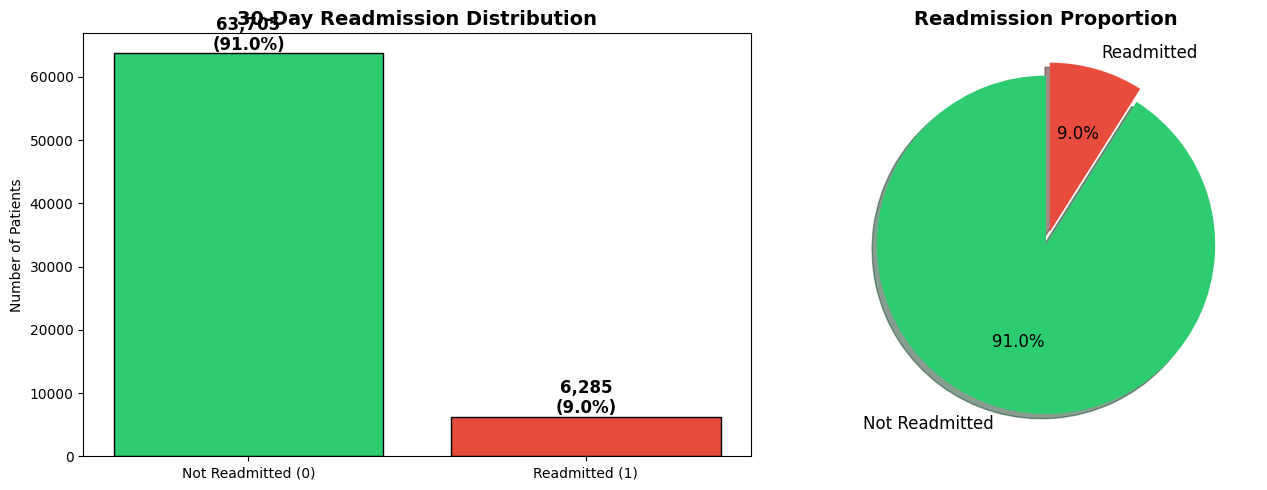


Insight: The dataset is imbalanced — only 6,285 (9.0%) patients were readmitted within 30 days.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['readmitted_30day'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Not Readmitted (0)', 'Readmitted (1)'], counts.values, color=colors, edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('30-Day Readmission Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')

# Pie chart
axes[1].pie(counts.values, labels=['Not Readmitted', 'Readmitted'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0, 0.08], shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Readmission Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/03_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nInsight: The dataset is imbalanced — only {counts[1]:,} ({counts[1]/len(df)*100:.1f}%) patients were readmitted within 30 days.")

## 3. Demographic Analysis
Exploring how age, gender, and race relate to readmission risk.

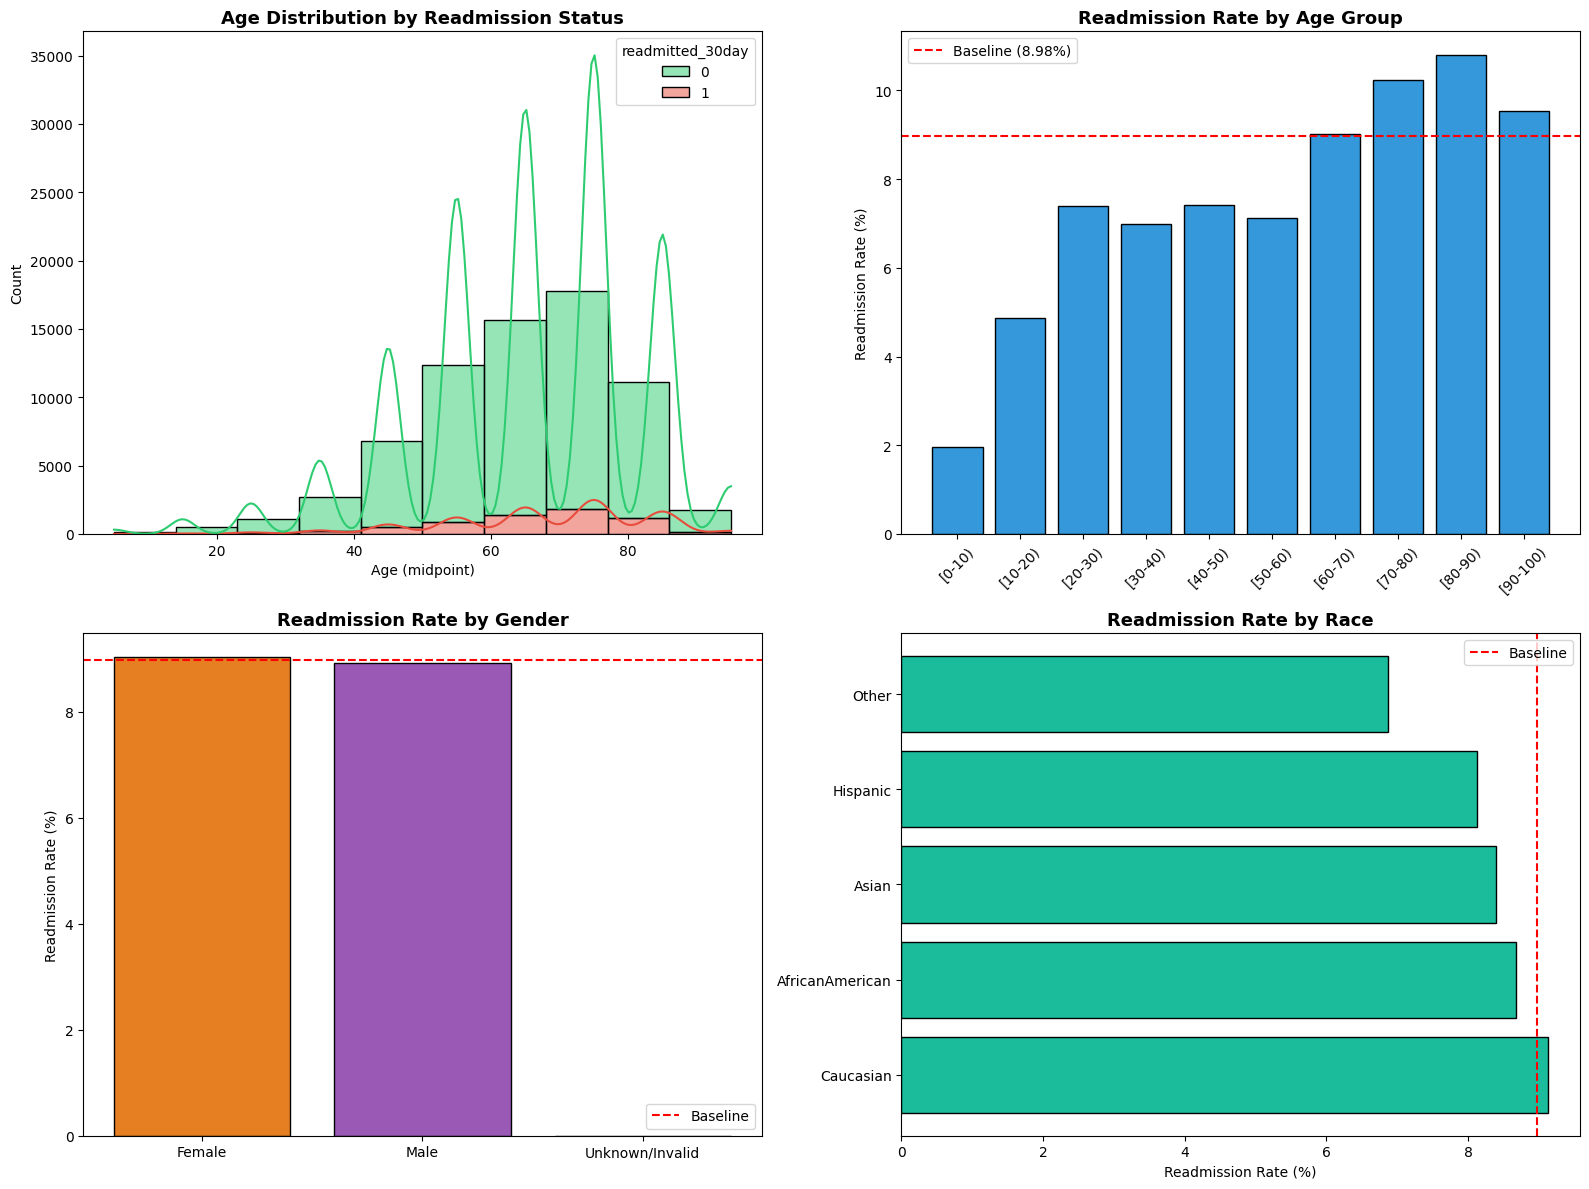

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution by readmission
sns.histplot(data=df, x='age', hue='readmitted_30day', bins=10, kde=True,
             ax=axes[0,0], palette={0: '#2ecc71', 1: '#e74c3c', '0': '#2ecc71', '1': '#e74c3c'}, multiple='stack')
axes[0,0].set_title('Age Distribution by Readmission Status', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Age (midpoint)')

# Readmission rate by age bracket
age_rates = df.groupby('age_bracket')['readmitted_30day'].mean().sort_index() * 100
axes[0,1].bar(age_rates.index, age_rates.values, color='#3498db', edgecolor='black')
axes[0,1].axhline(y=df['readmitted_30day'].mean()*100, color='red', linestyle='--', label='Baseline (8.98%)')
axes[0,1].set_title('Readmission Rate by Age Group', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Readmission Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()

# Gender distribution
gender_rates = df.groupby('gender')['readmitted_30day'].mean() * 100
axes[1,0].bar(gender_rates.index, gender_rates.values, color=['#e67e22', '#9b59b6', '#95a5a6'], edgecolor='black')
axes[1,0].axhline(y=df['readmitted_30day'].mean()*100, color='red', linestyle='--', label='Baseline')
axes[1,0].set_title('Readmission Rate by Gender', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Readmission Rate (%)')
axes[1,0].legend()

# Race distribution
race_rates = df.groupby('race')['readmitted_30day'].mean().sort_values(ascending=False) * 100
axes[1,1].barh(race_rates.index, race_rates.values, color='#1abc9c', edgecolor='black')
axes[1,1].axvline(x=df['readmitted_30day'].mean()*100, color='red', linestyle='--', label='Baseline')
axes[1,1].set_title('Readmission Rate by Race', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Readmission Rate (%)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/03_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Clinical Feature Distributions
Exploring the spread and skewness of key clinical indicators.

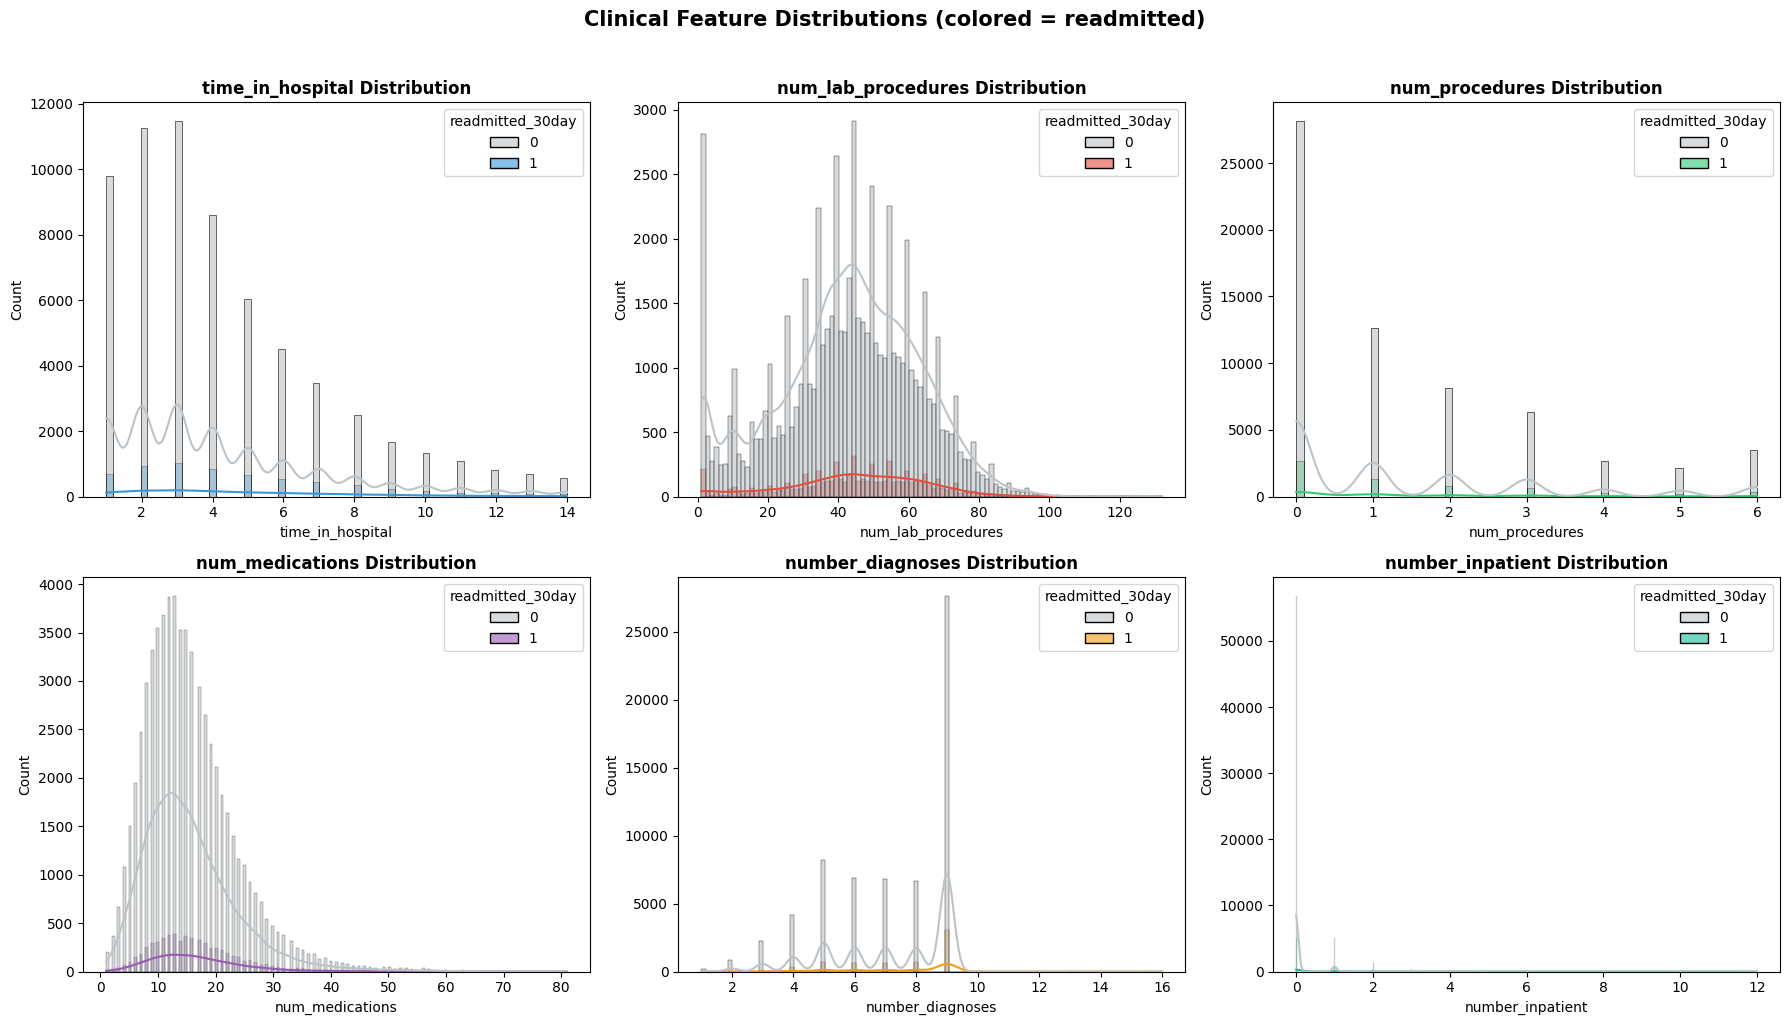

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
             'num_medications', 'number_diagnoses', 'number_inpatient']
colors_list = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for ax, col, color in zip(axes.flatten(), plot_cols, colors_list):
    sns.histplot(data=df, x=col, hue='readmitted_30day', kde=True,
                 ax=ax, palette={0: '#bdc3c7', 1: color, '0': '#bdc3c7', '1': color}, alpha=0.6)
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Clinical Feature Distributions (colored = readmitted)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/03_clinical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Medication & Treatment Analysis
How diabetes medication usage and insulin patterns relate to readmission.

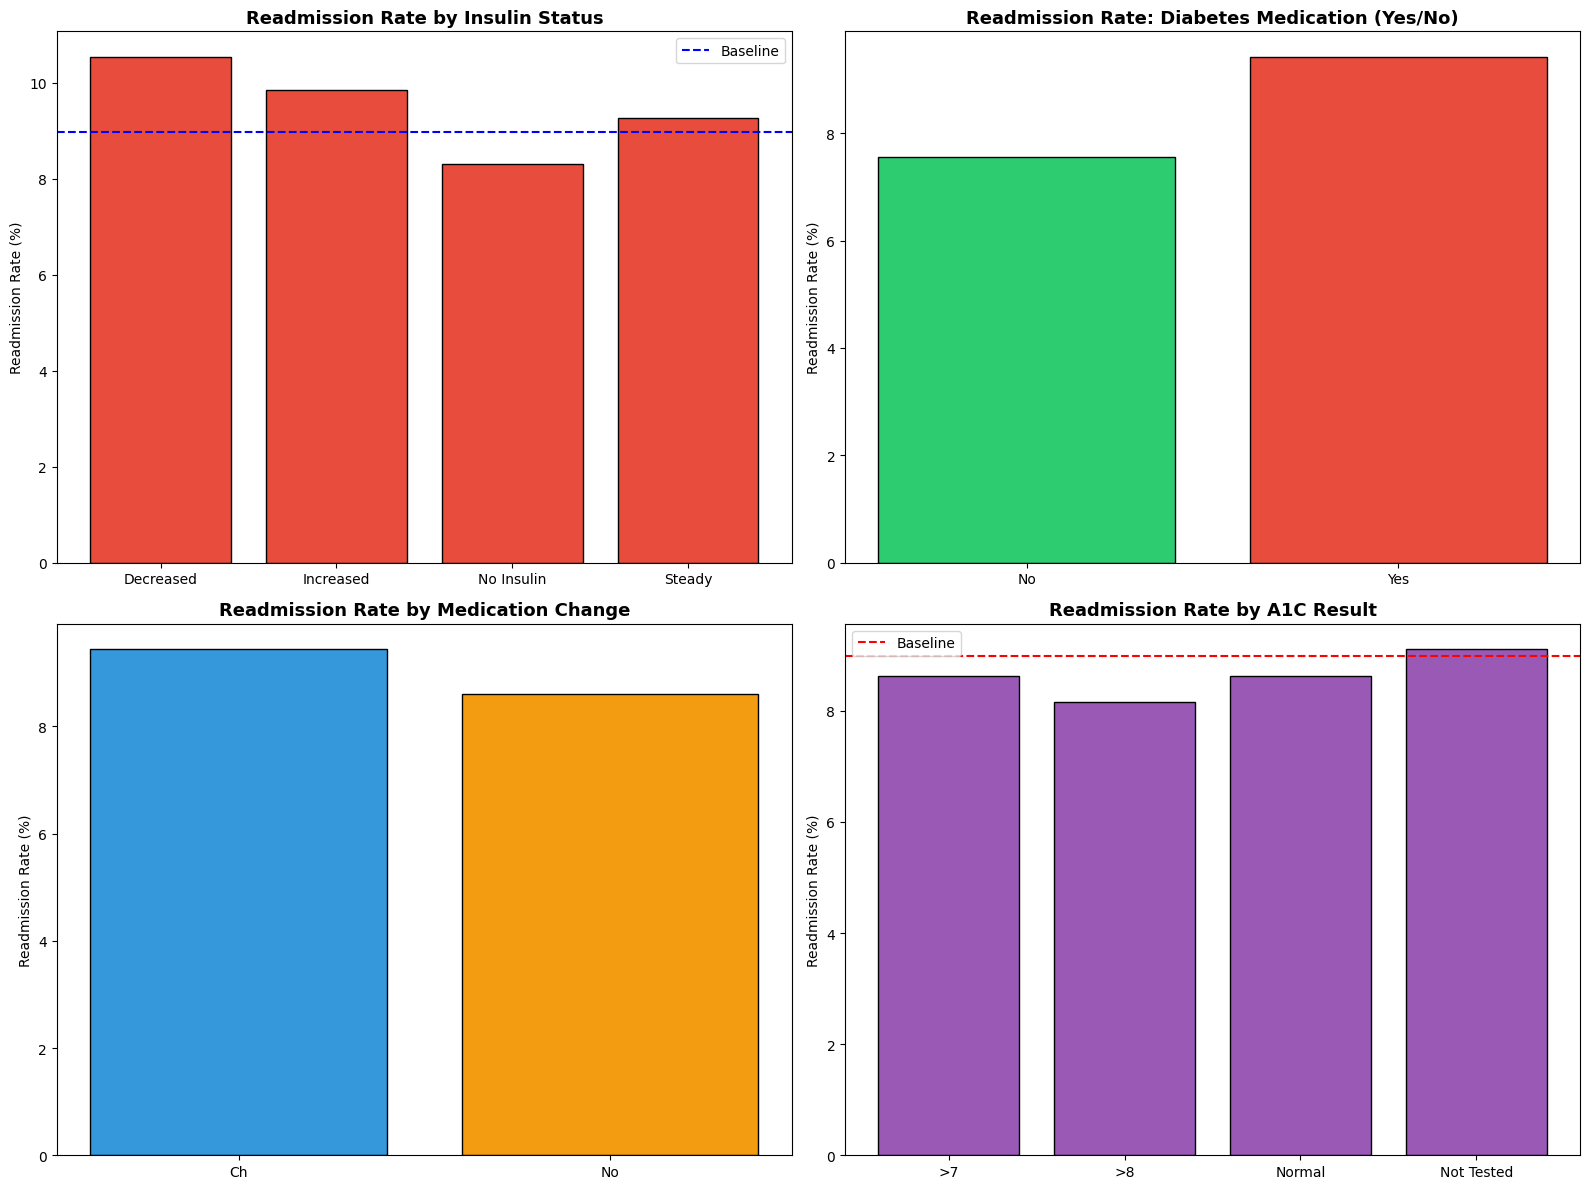

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Insulin usage vs readmission
insulin_labels = {0: 'No Insulin', 1: 'Steady', 2: 'Decreased', 3: 'Increased'}
temp = df.copy()
temp['insulin_label'] = temp['insulin'].map(insulin_labels)
insulin_rates = temp.groupby('insulin_label')['readmitted_30day'].mean() * 100
axes[0,0].bar(insulin_rates.index, insulin_rates.values, color='#e74c3c', edgecolor='black')
axes[0,0].axhline(y=df['readmitted_30day'].mean()*100, color='blue', linestyle='--', label='Baseline')
axes[0,0].set_title('Readmission Rate by Insulin Status', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Readmission Rate (%)')
axes[0,0].legend()

# Diabetes medication
dm_rates = df.groupby('diabetesmed')['readmitted_30day'].mean() * 100
axes[0,1].bar(dm_rates.index, dm_rates.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0,1].set_title('Readmission Rate: Diabetes Medication (Yes/No)', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Readmission Rate (%)')

# Medication change
change_rates = df.groupby('change')['readmitted_30day'].mean() * 100
axes[1,0].bar(change_rates.index, change_rates.values, color=['#3498db', '#f39c12'], edgecolor='black')
axes[1,0].set_title('Readmission Rate by Medication Change', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Readmission Rate (%)')

# A1C result vs readmission
a1c_labels = {0: 'Not Tested', 1: 'Normal', 2: '>7', 3: '>8'}
temp['a1c_label'] = temp['a1cresult'].map(a1c_labels)
a1c_rates = temp.groupby('a1c_label')['readmitted_30day'].mean() * 100
axes[1,1].bar(a1c_rates.index, a1c_rates.values, color='#9b59b6', edgecolor='black')
axes[1,1].axhline(y=df['readmitted_30day'].mean()*100, color='red', linestyle='--', label='Baseline')
axes[1,1].set_title('Readmission Rate by A1C Result', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Readmission Rate (%)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/03_medication_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hospital Stay & Admission Analysis
Exploring how admission type, discharge disposition, and length of stay impact readmission.

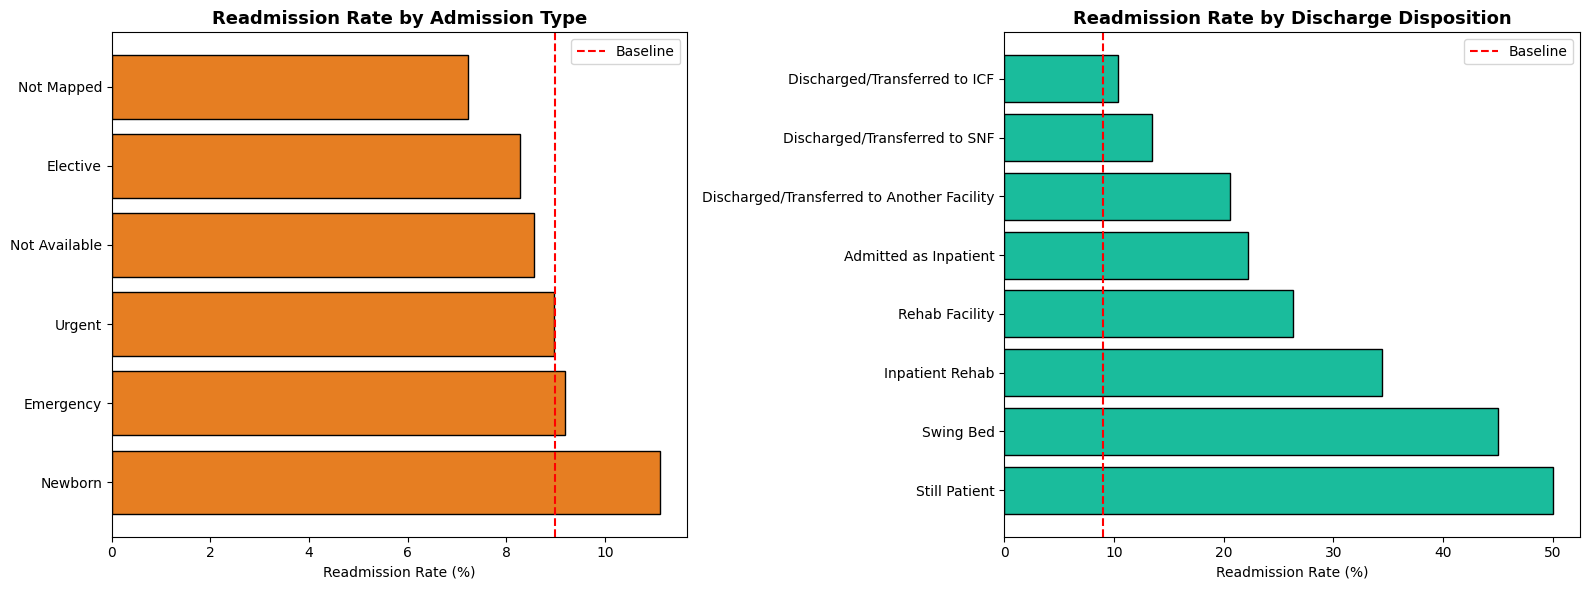

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Admission type vs readmission
adm_rates = df.groupby('admission_type_id')['readmitted_30day'].mean().sort_values(ascending=False) * 100
adm_rates = adm_rates.head(6)
axes[0].barh(adm_rates.index, adm_rates.values, color='#e67e22', edgecolor='black')
axes[0].axvline(x=df['readmitted_30day'].mean()*100, color='red', linestyle='--', label='Baseline')
axes[0].set_title('Readmission Rate by Admission Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Readmission Rate (%)')
axes[0].legend()

# Top discharge dispositions
dis_rates = df.groupby('discharge_disposition_id')['readmitted_30day'].mean().sort_values(ascending=False) * 100
dis_rates = dis_rates.head(8)
axes[1].barh(dis_rates.index, dis_rates.values, color='#1abc9c', edgecolor='black')
axes[1].axvline(x=df['readmitted_30day'].mean()*100, color='red', linestyle='--', label='Baseline')
axes[1].set_title('Readmission Rate by Discharge Disposition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Readmission Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/03_admission_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Primary Diagnosis Category Analysis
Which disease categories have the highest readmission rates?

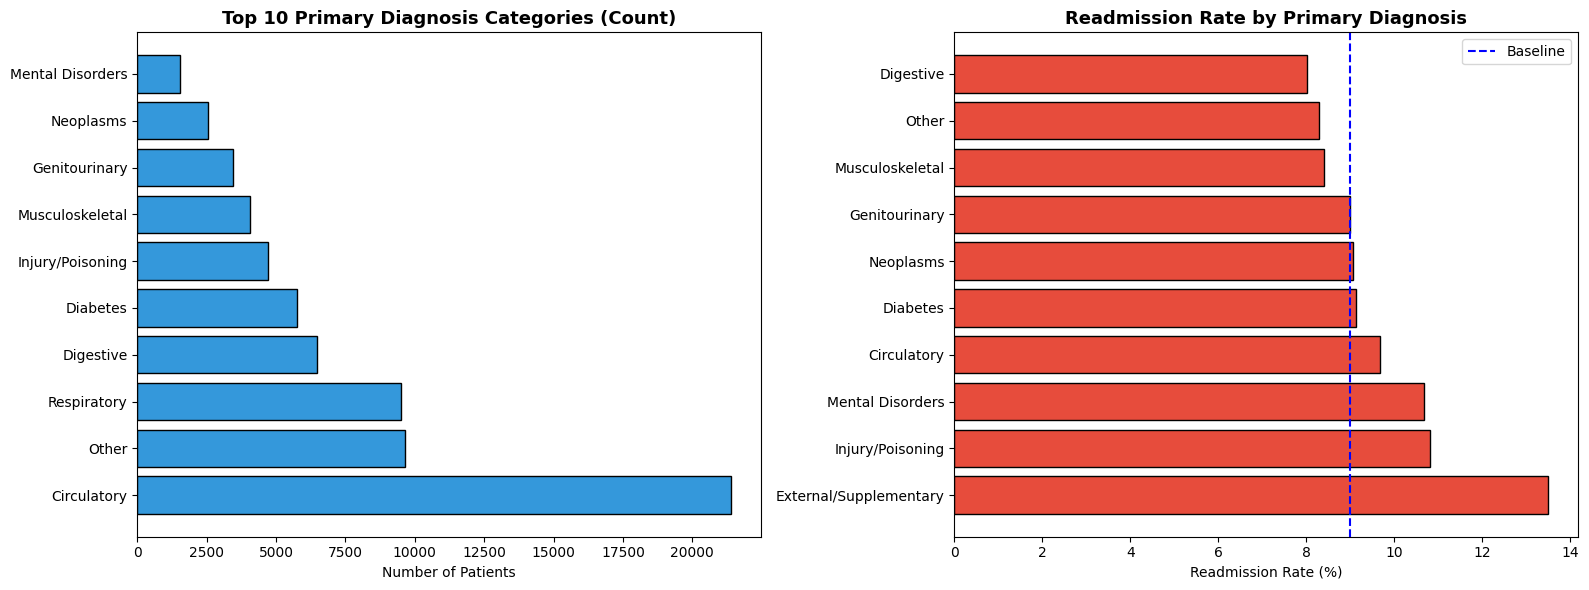

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diag_1 distribution
diag_counts = df['diag_1'].value_counts().head(10)
axes[0].barh(diag_counts.index, diag_counts.values, color='#3498db', edgecolor='black')
axes[0].set_title('Top 10 Primary Diagnosis Categories (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Patients')

# Diag_1 readmission rate
diag_rates = df.groupby('diag_1')['readmitted_30day'].mean().sort_values(ascending=False) * 100
diag_rates = diag_rates.head(10)
axes[1].barh(diag_rates.index, diag_rates.values, color='#e74c3c', edgecolor='black')
axes[1].axvline(x=df['readmitted_30day'].mean()*100, color='blue', linestyle='--', label='Baseline')
axes[1].set_title('Readmission Rate by Primary Diagnosis', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Readmission Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/03_diagnosis_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Prior Visit History & Chronic Patterns
Do patients with more prior hospital visits have higher readmission risk?

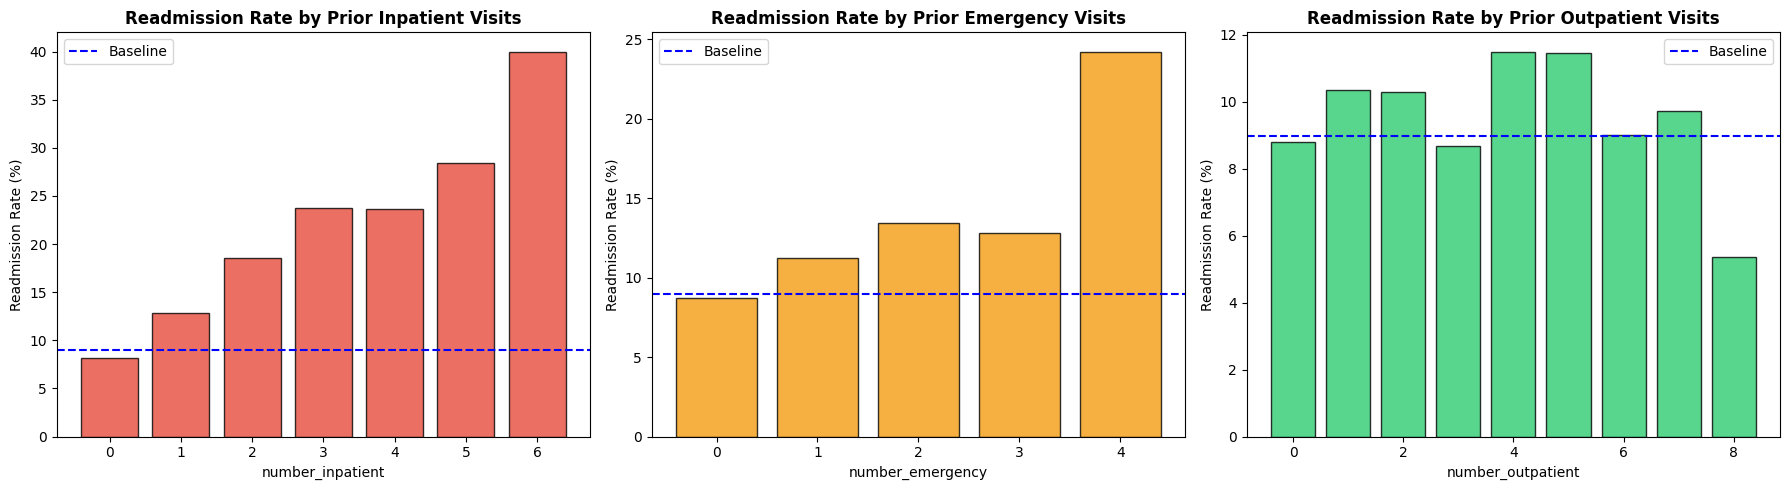

Insight: Patients with >= 2 prior inpatient visits show significantly elevated readmission rates.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title, color in zip(axes, 
    ['number_inpatient', 'number_emergency', 'number_outpatient'],
    ['Prior Inpatient Visits', 'Prior Emergency Visits', 'Prior Outpatient Visits'],
    ['#e74c3c', '#f39c12', '#2ecc71']):
    
    grouped = df.groupby(col)['readmitted_30day'].agg(['mean', 'count'])
    grouped = grouped[grouped['count'] >= 50]  # only groups with enough data
    ax.bar(grouped.index, grouped['mean'] * 100, color=color, edgecolor='black', alpha=0.8)
    ax.axhline(y=df['readmitted_30day'].mean()*100, color='blue', linestyle='--', label='Baseline')
    ax.set_title(f'Readmission Rate by {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Readmission Rate (%)')
    ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/03_prior_visits.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Patients with >= 2 prior inpatient visits show significantly elevated readmission rates.")

## 9. Outlier Detection
Identifying clinical anomalies using IQR method.

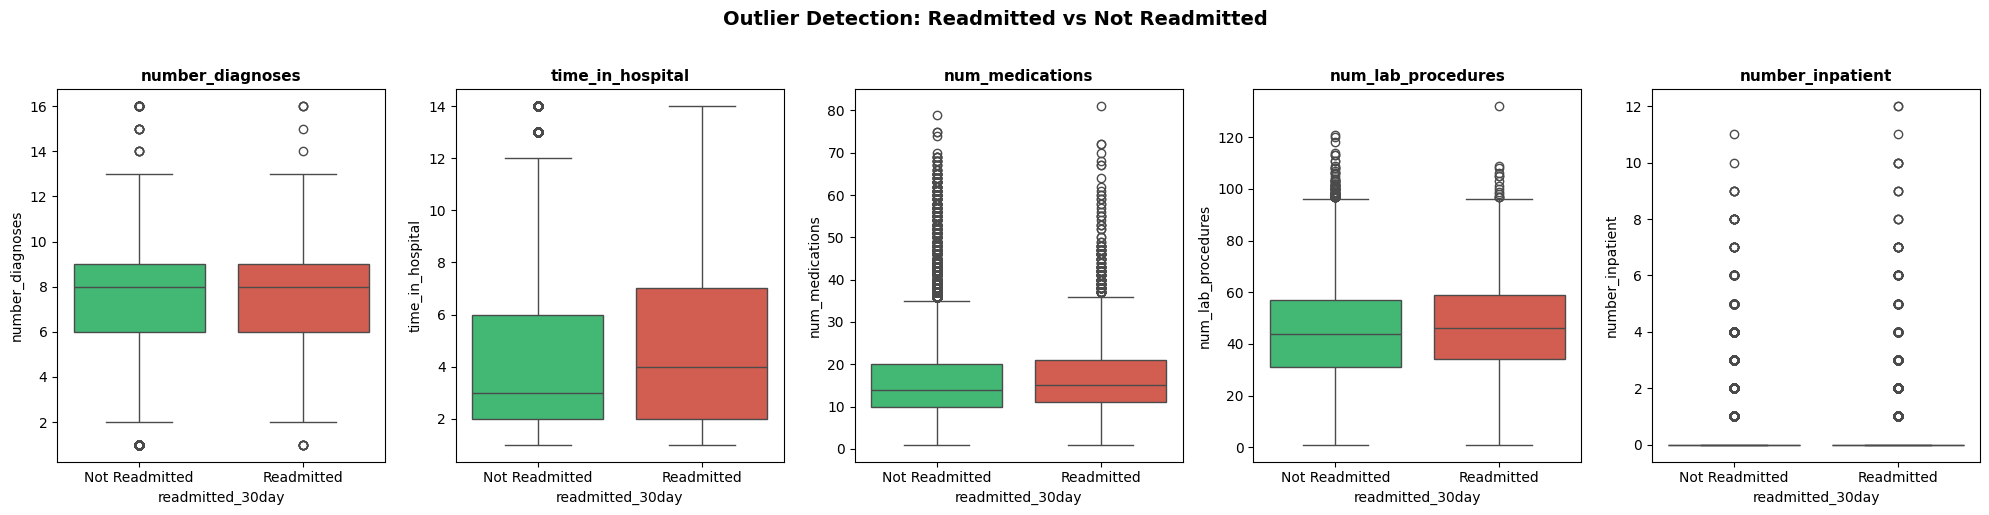


Outlier Counts (IQR Method):
  number_diagnoses: 235 outliers (0.34%)
  time_in_hospital: 1,403 outliers (2.00%)
  num_medications: 1,868 outliers (2.67%)
  num_lab_procedures: 98 outliers (0.14%)
  number_inpatient: 8,195 outliers (11.71%)


In [10]:
cols_to_check = ['number_diagnoses', 'time_in_hospital', 'num_medications',
                 'num_lab_procedures', 'number_inpatient']

fig, axes = plt.subplots(1, len(cols_to_check), figsize=(20, 5))

for ax, col in zip(axes, cols_to_check):
    sns.boxplot(data=df, y=col, x='readmitted_30day', ax=ax, palette={0: '#2ecc71', 1: '#e74c3c', '0': '#2ecc71', '1': '#e74c3c'})
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xticklabels(['Not Readmitted', 'Readmitted'])

plt.suptitle('Outlier Detection: Readmitted vs Not Readmitted', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/03_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOutlier Counts (IQR Method):")
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"  {col}: {len(outliers):,} outliers ({len(outliers)/len(df)*100:.2f}%)")

## 10. Key EDA Takeaways

| # | Finding | Business Implication |
|---|---|---|
| 1 | Only 8.98% patients readmitted within 30 days — highly imbalanced | Dashboard must highlight the minority high-risk group |
| 2 | Elderly patients (70-80) form the largest group and have elevated readmission rates | Target discharge interventions at this age segment |
| 3 | Patients with prior inpatient visits (≥2) show significantly higher readmission | Use visit history as a red flag in triage |
| 4 | Insulin adjustments (Up/Down) during stay correlate with higher readmission | Metabolic instability at discharge = readmission risk |
| 5 | High number of diagnoses (≥7) combined with old age is a strong risk pattern | Multi-morbid elderly patients need intensive follow-up |
| 6 | A1C testing was not performed for the majority of patients | Recommend mandatory A1C testing to improve outcomes |